# 🧪 AUTOMATIC KEYWORD EXTRACTION HYPERPARAMETER TUNING EXPERIMENT (FULL PIPELINE)
This notebook performs systematic hyperparameter tuning to find:
1. The mathematically optimal linear combination weights of normalized RAKE vs. IDF ($w_{rake} \cdot R_{norm} + w_{idf} \cdot I_{norm}$).
2. The optimal **Global Keyword Limit ($N$)** for processing full books (300+ pages) to prevent precision dilution.

It evaluates the trade-offs of Precision, Recall, and F1-Score against the human-curated ground-truth index (`real_index.json`).

### Key Features:
* **100% Identical Filtering:** Uses the exact same POS tagging, slang filters, length filtering, bigram correlation filtering, and reverse duplication removal as the production pipeline `chunked_pipeline_experiment.ipynb`.
* **Local Max RAKE:** Calculates RAKE page-by-page and aggregates via Maximum to capture localized central concepts.
* **Linear Weight Combination Tuning:** Normalizes RAKE and IDF scores to $[0, 1]$ and tests linear combinations.
* **Global Limit Tuning:** Tests global keyword limits $N \in [50, 800]$ to identify the mathematical peak for full books.

In [18]:
import os
import sys

# Setup Path
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
BE_DIR = os.path.join(PROJECT_ROOT, 'BE_generateBoBI')
if BE_DIR not in sys.path:
    sys.path.insert(0, BE_DIR)

# Auto-reload custom modules when they change
%load_ext autoreload
%autoreload 2

import pdf_helpers
import json
import Pages_to_pagesr
from tools import TitleOfWholeBooks
from indonesian import MyRAKE_indonesian as MyRAKE
from indonesian import WordEmbeddings_indonesian as CountWordEmb
import math
import collections
from docxtpl import DocxTemplate
from indonesian.indonesian_config import detect_language
import re
import ipywidgets as widgets
from IPython.display import display

print("Dependencies loaded!")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Dependencies loaded!


In [19]:
# Bypass the upload widget and point directly to the file
UPLOAD_FOLDER = os.path.join(BE_DIR, "userinput")
os.makedirs(UPLOAD_FOLDER, exist_ok=True)

pdf_filename = "Ekonomi_BS_KLS_XII.pdf" 
json_filename = None

# PROFIL BUKU
# Pilih "eksakta" untuk buku sains (Biologi/Fisika) yang fokus pada entitas langka (IDF tinggi)
# Pilih "sosial" untuk buku bahasa/sosial yang fokus pada konsep sentral berulang (RAKE tinggi)
book_category = "sosial"

pdf_path = os.path.join(UPLOAD_FOLDER, pdf_filename)
json_path = os.path.join(UPLOAD_FOLDER, json_filename) if json_filename else None

print(f"Ready to process PDF: {pdf_path}")

Ready to process PDF: e:\file\skripsi\code\rake\BE_generateBoBI\userinput\Ekonomi_BS_KLS_XII.pdf


In [20]:
# Prepare Pages and Titles
bookTitle = "Buku Ekonomi"
pages = []
pages_r = []
titles = {}

if json_path:
    with open(json_path, "r") as jsonFile:
        pages = json.load(jsonFile)
        pages_r = Pages_to_pagesr.convert(pages)
        titles = TitleOfWholeBooks.titleAndPageNumber(pages_r[0]["f"], pages_r[-1]["l"], pdf_path, pages_r)
        print("Pages and Titles extracted from JSON.")
else:
    # Manual mode if no json
    firstPage = 1 # Starting from page 1
    lastPage = 211  # End at page 66
    urutanPertama = 13 # The logical page sequence starts at physical page index offset
    pages = [{"f": firstPage, "l": lastPage, "d": (urutanPertama - firstPage)}]
    
    pages_r = Pages_to_pagesr.convert(pages)
    titles = TitleOfWholeBooks.titleAndPageNumber(pages_r[0]["f"], pages_r[-1]["l"], pdf_path, pages_r)
    print(f"Using manual page setup (Pages {firstPage} to {lastPage}).")

Using manual page setup (Pages 1 to 211).


In [21]:
# --- STEP 1: DETECT LANGUAGE, CLEAN & EXTRACT TEXT ---
def is_metadata_page_automatic(text, book_category="sosial"):
    """Detect metadata pages by measuring ratio of domain-specific terms."""
    domain_terms = set()
    if book_category == "eksakta":
        domain_terms = {
            'sel', 'organel', 'mitokondria', 'ribosom', 'vakuola', 'kloroplas',
            'nukleus', 'sitoplasma', 'membran', 'protein', 'enzim', 'dna', 'rna',
            'fotosintesis', 'respirasi', 'metabolisme', 'hormon', 'jaringan',
            'organ', 'sistem', 'mikroskop', 'prokariotik', 'eukariotik', 'virus',
            'bakteri', 'tumbuhan', 'hewan', 'manusia', 'darah', 'otak', 'jantung'
        }
    else: # sosial
        domain_terms = {
            'teks', 'paragraf', 'kalimat', 'cerita', 'puisi', 'narasi', 'dll',
            'bahasa', 'makna', 'kata', 'sastra', 'gagasan', 'topik', 'tulisan',
            'bacaan', 'informasi', 'pendapat', 'opini', 'fakta'
        }
    words = set(re.findall(r'\b\w+\b', text.lower()))
    overlap = len(words & domain_terms)
    return overlap < 3

def clean_textbook_text(text):
    """Clean Indonesian biology textbook text before keyword extraction."""
    text = re.sub(r'\b\d+\b', ' ', text)
    text = re.sub(r'\b\d+\s+\d+\s+\d+(?:\s+\d+)*\b', ' ', text)
    text = re.sub(r'\b\d{3}[\s\-]\d{1,5}[\s\-]\d{1,7}[\s\-]\d{1,6}[\s\-]\d\b', ' ', text)
    text = re.sub(r'\bisbn[\s\-]?\d+\b', ' ', text, flags=re.IGNORECASE)
    text = re.sub(r'https?://\S+|www\.\S+|\S+\.(com|org|id|gov|edu)\b', ' ', text)
    text = re.sub(r'\S+@\S+\.\S+', ' ', text)
    text = re.sub(r'[a-zA-Z]:\\[^ \n]*', ' ', text)
    text = re.sub(r'/\S+/\S+', ' ', text)
    text = re.sub(r'\b\w+\s+et\s+al\.?\b', ' ', text, flags=re.IGNORECASE)
    text = re.sub(r'\([12]\d{3}[a-z]?\)', ' ', text)
    
    # DYNAMIC FILTER: Remove all text enclosed in quotes (Removes story dialogs, anecdotes, quotes)
    text = re.sub(r'["“”][^"“”]*["“”]', ' ', text)
    # DYNAMIC FILTER: Remove dialogue blocks like "Budi : Halo"
    text = re.sub(r'^[A-Z][a-z]+(\s+[A-Z][a-z]+){0,2}\s*:\s*.*$', ' ', text, flags=re.MULTILINE)
    
    return ' '.join(text.split())

def remove_activity_sections(text):
    """Remove activity/practical sections from textbook text."""
    lines = text.split('\n')
    cleaned_lines = []
    in_activity = False
    activity_starters = [
        r'^\s*(kegiatan|aktivitas|demonstrasi|praktikum|eksplorasi|uji kompetensi)\s*\d*',
        r'^\s*(tujuan pembelajaran|capaian pembelajaran)',
        r'^\s*(alat dan bahan|prosedur|langkah kerja)',
        r'^\s*(kesimpulan|refleksi|diskusi|latihan|soal)\s*:?',
        r'^\s*ayo\s+', r'^\s*mari\s+', r'^\s*coba\s+',
        r'^\s*perhatikan\s+gambar', r'^\s*amati\s+',
        r'^\s*bacalah\s+', r'^\s*tuliskan\s+', r'^\s*jawablah\s+',
    ]
    for line in lines:
        line_stripped = line.strip().lower()
        if any(re.match(pattern, line_stripped) for pattern in activity_starters):
            in_activity = True
            continue
        if in_activity and (line_stripped == '' or re.match(r'^[A-Z][a-z]+', line_stripped)):
            in_activity = False
        if not in_activity:
            cleaned_lines.append(line)
    return '\n'.join(cleaned_lines)

def remove_figure_captions(text):
    """Remove figure captions, photo credits, and source attributions."""
    text = re.sub(r'\bgambar\s+\d+[\.\d]*\s*[^\n]*', ' ', text, flags=re.IGNORECASE)
    text = re.sub(r'\bsumber\s*[:;]\s*[^\n]+', ' ', text, flags=re.IGNORECASE)
    text = re.sub(r'\bpexels\b|\bunsplash\b|\bpixabay\b', ' ', text, flags=re.IGNORECASE)
    text = re.sub(r'\b(foto|photo|image)\s*[:;]\s*[^\n]+', ' ', text, flags=re.IGNORECASE)
    return text

page_info = pages[0]
start_page = page_info["f"]
end_page = page_info["l"]
delta = page_info["d"]

page_text_raw = ""
pages_text_list = []
print(f"Mengekstrak teks dari halaman {start_page} sampai {end_page}...")

for p in range(start_page, end_page + 1):
    actual_pdf_page = p + delta - 1
    pt_raw = pdf_helpers.extract_text_from_a_page(pdf_path, actual_pdf_page)
    pages_text_list.append(pt_raw)
    page_text_raw += pt_raw + "\n\n"

target_page = start_page
language = detect_language(page_text_raw)

print(f"Detected language: {language}")

if is_metadata_page_automatic(page_text_raw, book_category):
    print(f"\nWARNING: Teks terdeteksi sebagai halaman METADATA/AWAL BUKU (Terms biologi sangat sedikit). Hasil kata kunci mungkin buruk.")

# Clean text globally
page_text = remove_activity_sections(page_text_raw)
page_text = remove_figure_captions(page_text)
page_text = clean_textbook_text(page_text)

# Clean text locally per page
cleaned_pages_text = []
for pt in pages_text_list:
    c_pt = remove_activity_sections(pt)
    c_pt = remove_figure_captions(c_pt)
    c_pt = clean_textbook_text(c_pt)
    cleaned_pages_text.append(c_pt)

print(f"\n--- EXTRACTED & CLEANED RAW TEXT (First 500 chars) ---")
print(page_text[:500] + "... [TRUNCATED]")

Mengekstrak teks dari halaman 1 sampai 211...
Detected language: indonesian

--- EXTRACTED & CLEANED RAW TEXT (First 500 chars) ---
BAB Pertumbuhan dan Pembangunan Ekonomi Dalam bab ini, kalian akan mempelajari pertumbuhan dan pembangunan ekonomi. Setelah pembelajaran, kalian diharapkan mampu menjelaskan konsep pertumbuhan dan pembangunan ekonomi serta menganalisis fenomena pertumbuhan, dan pembangunan ekonomi di Indonesia. KEMENTERIAN PENDIDIKAN, KEBUDAYAAN, RISET, DAN TEKNOLOGI REPUBLIK INDONESIA, Buku Siswa Ekonomi untuk SMA/MA Kelas XII Penulis: Aisyah Nurjanah dan Yeni Fitriani ISBN - - - - (jil. ) ● EKONOMI UNTUK SMA/M... [TRUNCATED]


In [22]:
# --- STEP 2: LOAD CORPUS, EXTRACT DYNAMIC STOPWORDS & RUN RAKE ---
corpus_path = os.path.join(BE_DIR, "corpus", "books_indexing_corpus.txt")
corpus_word_counts = collections.Counter()
total_corpus_words = 0
corpus_text = ""

print("Loading corpus from:", corpus_path)
if os.path.exists(corpus_path):
    with open(corpus_path, "r", encoding="utf-8", errors="ignore") as f:
        corpus_text = f.read().lower()
        corpus_words = re.findall(r'\b\w+\b', corpus_text)
        corpus_word_counts.update(corpus_words)
        total_corpus_words = len(corpus_words)
    print(f"Corpus loaded! Total words: {total_corpus_words}")
else:
    print("Corpus not found.")

def extract_dynamic_stopwords(corpus_txt, top_n=200):
    from collections import Counter
    documents = corpus_txt.split('\n') # Assume each line/paragraph is a document
    total_docs = len(documents)
    if total_docs == 0: return set()
    
    word_doc_count = Counter()
    for doc in documents:
        words = set(re.findall(r'\b\w+\b', doc.lower()))
        for w in words:
            word_doc_count[w] += 1
            
    stopwords = set()
    for word, doc_count in word_doc_count.most_common():
        if doc_count == total_docs:
            stopwords.add(word)
        elif doc_count / total_docs > 0.9 and len(word) > 2:
            stopwords.add(word)
        if len(stopwords) >= top_n:
            break
    return stopwords

PROTECTED_DOMAIN_WORDS = set()
if book_category == "eksakta":
    PROTECTED_DOMAIN_WORDS = {'sel', 'organel', 'mitokondria', 'membran', 'protein', 'enzim', 'fotosintesis', 'respirasi', 'nukleus'}
else: # sosial
    PROTECTED_DOMAIN_WORDS = {'teks', 'paragraf', 'narasi', 'deskripsi', 'eksposisi', 'prosedur', 'argumentasi', 'puisi', 'cerpen', 'novel', 'drama', 'kalimat', 'diksi', 'majas', 'alinea'}

dynamic_stopwords = extract_dynamic_stopwords(corpus_text, top_n=200) if corpus_text else set()
dynamic_stopwords = dynamic_stopwords - PROTECTED_DOMAIN_WORDS
print(f"Extracted {len(dynamic_stopwords)} dynamic stopwords from corpus.")

METADATA_NOISE = {
    # Data buku
    "isbn", "penulis", "penerbit", "editor", "revisi", "cetakan",
    "kementerian", "pendidikan", "kebudayaan", "riset", "teknologi",
    "republik", "indonesia", "jakarta", "2022", "2021", "2020",
    "sma", "kelas", "xi", "x", "xii", "semester",
    
    # Referensi asing
    "national", "institute", "allergy", "infectious", "diseases",
    "journal", "volume", "issue", "page", "doi", "url",
    "scott", "phil", "cdc", "gov", "details", "aspx", "pid", "subowo",
    
    # Format aktivitas
    "kegiatan", "aktivitas", "demonstrasi", "praktikum", "eksplorasi",
    "judul", "tujuan", "alat", "bahan", "prosedur", "langkah",
    "kesimpulan", "refleksi", "diskusi", "latihan", "soal",
    
    # Instruksi
    "perhatikan", "amati", "coba", "kerjakan", "jawablah",
    "tuliskan", "bacalah", "pahami", "analisis", "identifikasi",
    "sebutkan", "jelaskan", "uraikan", "tunjukkan", "buktikan",
    "mari", "ayo", "baiklah", "ingat", "ingatlah",
    "jelajah", "jelajahi", "jelajahilah", "temukan", "carilah", "tentukan",
    
    # Panggilan
    "bapak", "ibu", "guru", "siswa", "anak", "kalian",
    
    # Digital
    "https", "tautan", "link", "virtuallabs", "virtual", "labs",
    "petunjuk", "panduan", "manual", "download", "video",
    
    # Tambahan: Kata Kerja Umum & Relasional
    "melakukan", "menyebabkan", "disebabkan", "mengandung", "memiliki", 
    "berupa", "merupakan", "terdiri", "menunjukkan", "menyatakan", "menguraikan",
    "akibatnya", "akibat", "berperan", "sebagai", "bagian", "sebagian", "besar",
    "salah", "satu", "tipe", "kondisi", "sifat", "umumnya", "khususnya",
    "antara", "sangat", "baik", "penyaji", "konektor", "asosiasi", "terfasilitasi",
    "pembentuk", "pembentukannya", "penyusun", "penyusunnya", "penghasil", "pengatur",
    "pembawa", "penerima", "penyebab", "penghubung", "pembatas", "penyaring",
    
    # Tambahan aktivitas
    "kata", "kunci", "diharapkan", "mampu", "mengeksplorasi", "memahami",
    "menjelaskan", "menganalisis", "mengidentifikasi", "hasilnya", "kasi",
    "pengamatan", "pengamat", "mengamati", "penemuan", "menemukan",
    "perkembangan", "berkembang", "mengendalikan", "kendali",
    "tempat", "terjadi", "peta", "konsep", "teori", "skrining",
    "keunggulan", "kelemahan", "isinya", "ringkas", "ringkasan", "mandiri", "pertanyaan", "halaman"
}
METADATA_NOISE.update(dynamic_stopwords)

VALID_BIGRAMS = {
    'membran sel', 'membran plasma', 'sel prokariotik', 'sel eukariotik',
    'struktur sel', 'fungsi organel', 'lokasi organel', 'transpor zat',
    'inti sel', 'badan golgi', 'retikulum endoplasma', 'kompleks golgi',
    'sel darah', 'jaringan epitel', 'jaringan ikat', 'jaringan otot',
    'jaringan saraf', 'sistem organ', 'organ tubuh'
}

def is_informal_word(word):
    if len(word) <= 3:
        return False
    # ng-/ny- prefix = slang reduction of meng-/meny-
    if word.startswith(('ng', 'ny')) and len(word) > 4:
        return True
    # -in suffix = slang (masukin, dateng → not this, but culik-in etc.)
    if word.endswith('in') and not word.endswith(('latin', 'utin', 'satin')):
        return True
    # Common slang markers
    slang_words = {
        'dateng', 'nongol', 'nongolnya', 'gimana', 'kayak', 'gitu',
        'udah', 'udahnya', 'emang', 'banget', 'dong', 'deh', 'sih',
        'nih', 'loh', 'kan', 'aja', 'doang', 'gak', 'nggak', 'enggak',
        'abis', 'terus', 'trus', 'kalo', 'kalau', 'sama', 'yg', 'dgn',
        'labu', 'minggu', 'malem', 'malem', 'kelar', 'nyampe'
    }
    if word in slang_words:
        return True
    return False

def is_valid_keyword_pattern(phrase):
    """
    Keep only phrases that match valid grammatical patterns for Indonesian index entries.
    Uses lightweight morphological & part-of-speech heuristics.
    """
    words = phrase.lower().split()
    if not words or len(words) > 4:
        return False
        
    # Reject words containing digits, underscores, or other non-alphabetic/non-hyphen characters
    for w in words:
        if not re.match(r'^[a-zA-Z\-]+$', w):
            return False
            
    # Reject phrases containing informal/slang words
    if any(is_informal_word(w) for w in words):
        return False
        
    # Indonesian functional words (prepositions, conjunctions, pronouns, common non-index verbs)
    functional_words = {
        'yang', 'dan', 'atau', 'dari', 'pada', 'untuk', 'dengan', 'ke', 'di', 
        'ini', 'itu', 'adalah', 'yaitu', 'sebagai', 'oleh', 'dalam', 'secara', 
        'terhadap', 'bahwa', 'pun', 'saja', 'seperti', 'maupun', 'serta', 'tentang',
        'akan', 'telah', 'sudah', 'dapat', 'bisa', 'ingin', 'harus', 'olehnya'
    }
    
    # Heuristics for Indonesian POS estimation
    noun_suffixes = ('an', 'asi', 'isasi', 'itas', 'ologi', 'ografi', 'isme', 'ur', 'at', 'el')
    verb_prefixes = ('me', 'mem', 'men', 'meng', 'meny', 'di', 'ber', 'ter')
    
    def estimate_pos(word):
        if word in functional_words:
            return 'FUNC'
        
        # Generalized English loan gerunds/verbs in Indonesian ending in "-ing" (like 'skrining', 'kloning', 'scanning')
        native_ing_words = {
            'dinding', 'kucing', 'piring', 'cacing', 'kambing', 'kepiting', 'tebing', 
            'suling', 'taring', 'keping', 'seruling', 'kuping', 'kancing', 'daging',
            'kuning', 'sering', 'asing', 'penting', 'garing', 'kering', 'ramping', 
            'pening', 'bening', 'hening', 'bising', 'miring', 'giring', 'jaring', 
            'pancing', 'saring', 'tanding', 'banting', 'anting', 'samping', 'damping',
            'ranting', 'genting', 'sinting', 'tengking', 'tuding'
        }
        if word.endswith('ing') and word not in native_ing_words:
            return 'VERB'
            
        # Crucial Fix: Verbs ending in causative suffix -kan or -i (e.g. "menurunkan", "mengatasi")
        # should be VERB even though -kan ends with "an" (which otherwise looks like a NOUN suffix)
        if (word.endswith('kan') or (word.endswith('i') and not word.endswith(('ologi', 'ografi')))) and any(word.startswith(pref) for pref in verb_prefixes):
            return 'VERB'
        if word.endswith(noun_suffixes):
            return 'NOUN'
        if any(word.startswith(pref) for pref in verb_prefixes):
            if word in {'terutama', 'tersebut', 'terhadap', 'bersama', 'berbagai', 'berikut'}:
                return 'FUNC'
            return 'VERB'
        return 'NOUN_OR_ADJ'

    pos_tags = [estimate_pos(w) for w in words]
    
    # 1. Invalid: Starts with a verb or functional word (e.g. "mengamati sel", "yang benar")
    if pos_tags[0] in ('VERB', 'FUNC'):
        return False
        
    # 2. Invalid: Ends with a verb or functional word (e.g. "sel yang", "membran untuk")
    if pos_tags[-1] in ('VERB', 'FUNC'):
        return False
        
    # 3. Invalid: Too many functional words (index entries typically have at most one)
    func_count = pos_tags.count('FUNC')
    if func_count > 1:
        return False
        
    # 4. Check if there is at least one content word (Noun/Adj)
    has_content = any(t in ('NOUN', 'NOUN_OR_ADJ') for t in pos_tags)
    if not has_content:
        return False
        
    return True

def is_noise_phrase(phrase):
    words = phrase.lower().split()
    if not words: return True
    if any(re.match(r'^(19|20)\d{2}$', w) for w in words): return True
    if 'isbn' in words or any(re.match(r'^\d{3}[\s\-]\d{3}', w) for w in words): return True
    if 'dkk' in words or 'dk' in words: return True
    institution_words = ['kementerian', 'republik', 'indonesia', 'national', 'institute']
    if any(w in words for w in institution_words): return True
    noise_starts = ['perhatikan', 'amati', 'coba', 'kerjakan', 'jawablah',
                    'tuliskan', 'bacalah', 'mari', 'ayo', 'ditunjukkan',
                    'ingat', 'ingatlah']
    if any(phrase.lower().startswith(w) for w in noise_starts): return True
    if any(w in words for w in ['bapak', 'ibu', 'guru', 'siswa', 'kalian']): return True
    activity_only = all(w in METADATA_NOISE for w in words)
    if activity_only: return True
    activity_words = {'pengamatan', 'pengamat', 'penemuan', 'perkembangan', 
                      'peta', 'konsep', 'mengendalikan', 'kendali'}
    biology_words = {'sel', 'organel', 'mitokondria', 'ribosom', 'mikroskop',
                     'prokariotik', 'eukariotik', 'nukleus', 'sitoplasma'}
    has_activity = any(w in words for w in activity_words)
    has_biology = any(w in words for w in biology_words)
    if phrase.lower() == "teori sel": return False
    if has_activity and has_biology and len(words) > 3: return True
    filler_words = {'pentingnya', 'penyusun', 'sejarah', 'tempat', 'terjadi'}
    if any(w in words for w in filler_words): return True
    if phrase.lower() in ['sel sejarah', 'sel tempat', 'organel pentingnya']: return True
    return False

def split_long_phrase(phrase):
    words = phrase.split()
    if len(words) <= 4:
        return [phrase]
    biology_terms = {'sel', 'organel', 'mitokondria', 'ribosom', 'vakuola',
                     'kloroplas', 'nukleus', 'sitoplasma', 'membran',
                     'mikroskop', 'prokariotik', 'eukariotik', 'virus', 'bakteri'}
    sub_phrases = []
    current = []
    for w in words:
        current.append(w)
        if w in biology_terms and len(current) >= 2:
            sub_phrases.append(' '.join(current))
            current = [w]
    if current and len(current) > 1:
        sub_phrases.append(' '.join(current))
    return sub_phrases if sub_phrases else [phrase]

def filter_phrase_length(phrases, min_words=1, max_words=3):
    filtered = {}
    for phrase, score in phrases.items():
        word_count = len(phrase.split())
        if min_words <= word_count <= max_words:
            filtered[phrase] = score
    return filtered

def is_meaningful_bigram(word1, word2, text):
    pattern = rf'\b{re.escape(word1)}\s+\w{{0,3}}\s*{re.escape(word2)}\b'
    matches = len(re.findall(pattern, text, re.IGNORECASE))
    return matches >= 2

def filter_bigrams(phrases, text):
    filtered = {}
    for phrase, score in phrases.items():
        words = phrase.split()
        if len(words) == 2:
            if phrase.lower() in VALID_BIGRAMS:
                filtered[phrase] = score
            else:
                if is_meaningful_bigram(words[0], words[1], text):
                    filtered[phrase] = score
        else:
            filtered[phrase] = score
    return filtered

def remove_reverse_duplicates(phrases):
    seen = set()
    filtered = {}
    for phrase, score in phrases.items():
        words = phrase.lower().split()
        normalized = ' '.join(sorted(words))
        if normalized not in seen:
            seen.add(normalized)
            filtered[phrase] = score
        else:
            if phrase.lower() in VALID_BIGRAMS:
                reverse = ' '.join(words[::-1])
                if reverse in filtered:
                    del filtered[reverse]
                filtered[phrase] = score
    return filtered

# Initialize RAKE with custom + dynamic stopwords
# Menggunakan LOCAL MAX RAKE (Skor dihitung per-halaman, diambil maksimum)
raw_rake_results = {}
for pt in cleaned_pages_text:
    if not pt.strip(): continue
    rake_local = MyRAKE.Rake(language=language, custom_stopwords=METADATA_NOISE)
    rake_local.extract_keywords_from_text(pt)
    pg_scores = dict(rake_local.get_ranked_keywords())
    for kw, sc in pg_scores.items():
        raw_rake_results[kw] = max(raw_rake_results.get(kw, 0), sc)

# 1. Post-extraction filter & Split
rakeIndex = {}
for kw, score in raw_rake_results.items():
    if not is_noise_phrase(kw) and is_valid_keyword_pattern(kw):
        sub_phrases = split_long_phrase(kw)
        for sp in sub_phrases:
            if not is_noise_phrase(sp) and is_valid_keyword_pattern(sp):
                rakeIndex[sp] = max(rakeIndex.get(sp, 0), score)

# 2. Length filter (Maksimal 3 kata)
rakeIndex = filter_phrase_length(rakeIndex, 1, 3)

# 3. Bigram filter
rakeIndex = filter_bigrams(rakeIndex, page_text)

# 4. Remove reverse duplicates
rakeIndex = remove_reverse_duplicates(rakeIndex)

# 5. DYNAMIC FREQUENCY FILTER: Untuk buku sosial/bahasa, konsep harus muncul > 1 kali
# Hal ini menghilangkan noise (seperti nama tokoh cerita atau slang unik) yang lolos filter kutipan
if book_category == "sosial":
    global_text_lower = page_text_raw.lower()
    filtered_by_freq = {}
    for kw, score in rakeIndex.items():
        # Count approximate occurrences globally
        if global_text_lower.count(kw) >= 1:
            filtered_by_freq[kw] = score
    rakeIndex = filtered_by_freq

print(f"Found {len(rakeIndex)} potential keywords (after filtering noise, splitting & deduping).")
print("\n--- TOP 10 KEYWORDS BY BASE RAKE SCORE ---")

sorted_initial = sorted(rakeIndex.items(), key=lambda x: x[1], reverse=True)
for kw, score in sorted_initial[:10]:
    print(f" - {kw}: {score:.2f}")

Loading corpus from: e:\file\skripsi\code\rake\BE_generateBoBI\corpus\books_indexing_corpus.txt
Corpus loaded! Total words: 2488757
Extracted 0 dynamic stopwords from corpus.
Found 1564 potential keywords (after filtering noise, splitting & deduping).

--- TOP 10 KEYWORDS BY BASE RAKE SCORE ---
 - tabungan masyarakat proporsional: 60.00
 - masyarakat digunakan penuh: 60.00
 - penetapan bea impor: 54.17
 - tingkat profitabilitas perusahaan: 51.67
 - masyarakat luar negeri: 51.00
 - satuan mata uang: 48.00
 - jasa perbedaan pengetahuan: 45.00
 - posisi keuangan perusahaan: 42.00
 - peniadaan hambatan tarif: 42.00
 - organisasi perdagangan dunia: 37.67


In [23]:
# --- STEP 3: LOAD GROUND TRUTH ---
import json
import os

bookname = os.path.splitext(pdf_filename)[0].lower().replace(" ", "_").replace("-", "_")
json_index_path = f"index/real_index_{bookname}.json"
ground_truth = []

if os.path.exists(json_index_path):
    print(f"Reading Ground Truth from {json_index_path}...")
    with open(json_index_path, 'r', encoding='utf-8') as f:
        real_index_data = json.load(f)
    ground_truth = [gt.lower() for gt in real_index_data.keys()]
    print(f"Ground Truth loaded! Total: {len(ground_truth)} keywords.")
else:
    print(f"WARNING: File {json_index_path} not found!")


Reading Ground Truth from index/real_index_ekonomi_bs_kls_xii.json...
Ground Truth loaded! Total: 67 keywords.


In [24]:
# --- STEP 4: LINEAR COMBINATION TUNING (WITH GRAPH-LAYER RAKE SCORING & FUZZY MATCHING) ---
import networkx as nx
import math
from difflib import SequenceMatcher

def get_phrase_idf(phrase):
    if total_corpus_words == 0: return 1.0
    words = re.findall(r'\b\w+\b', phrase.lower())
    if not words: return 1.0
    idf_sum = 0
    for w in words:
        count = corpus_word_counts.get(w, 0) + 1
        idf_sum += math.log10(total_corpus_words / count)
    return idf_sum / len(words)

def extract_subchapter_titles(text):
    titles = []
    lines = text.split('\n')
    for line in lines:
        line = line.strip()
        if re.match(r'^([A-Z]\.|[0-9]+\.)\s+[A-Z]', line):
            clean = re.sub(r'^([A-Z]\.|[0-9]+\.)\s+', '', line)
            titles.append(clean)
        elif line.isupper() and 10 < len(line) < 100:
            titles.append(line.title())
    return titles

title_list = extract_subchapter_titles(page_text)
if not title_list:
    title_list = [bookTitle]

print(f"Comparing keywords against dynamic titles: {title_list}")

# === GA-RAKE GRAPH BUILDING ===
print("\nBuilding Graph-Layer RAKE (GA-RAKE)...")

# Layer 1: Word-Phrase Bipartite Graph
G1 = nx.Graph()
for phrase, score in rakeIndex.items():
    G1.add_node(phrase, type="phrase")
    words = phrase.split()
    for w in words:
        G1.add_node(w, type="word")
        G1.add_edge(phrase, w, weight=score)

# Layer 2: Word-Word Co-occurrence Graph
G2 = nx.Graph()
words_in_text = re.findall(r'\b\w+\b', page_text.lower())
filtered_words = [w for w in words_in_text if w not in METADATA_NOISE]

window_size = 3
for i, w1 in enumerate(filtered_words):
    if w1 not in G2:
        G2.add_node(w1, type="word")
    start = max(0, i - window_size)
    end = min(len(filtered_words), i + window_size + 1)
    for j in range(start, end):
        if i != j:
            w2 = filtered_words[j]
            if G2.has_edge(w1, w2):
                G2[w1][w2]['weight'] += 1
            else:
                G2.add_edge(w1, w2, weight=1)

# Layer 3: Graph-Layer RAKE Scoring (no PageRank)
G_combined = nx.compose(G1, G2)

phrase_weight = {}  # word -> sum of RAKE scores of phrases it belongs to
for phrase, score_dict in rakeIndex.items():
    rake_score = score_dict if isinstance(score_dict, (int, float)) else score_dict.get("rake", 0)
    for word in phrase.lower().split():
        phrase_weight[word] = phrase_weight.get(word, 0) + rake_score

cooc_degree = {}  # word -> sum of co-occurrence edge weights
for node in G2.nodes():
    cooc_degree[node] = sum(
        data.get("weight", 1) 
        for _, _, data in G2.edges(node, data=True)
    )

graph_word_scores = {}
for word in phrase_weight:
    degree = cooc_degree.get(word, 1)
    graph_word_scores[word] = phrase_weight[word] * math.log1p(degree)

max_graph_score = max(graph_word_scores.values()) if graph_word_scores else 1.0
if max_graph_score == 0:
    max_graph_score = 1.0

# Precomputing features for each keyword to run tuning extremely fast
precomputed = {}
max_rake = max(rakeIndex.values()) if rakeIndex else 1.0
calculated_max_idf = max(get_phrase_idf(k) for k in rakeIndex) if rakeIndex else 5.91
max_idf = calculated_max_idf if calculated_max_idf > 0 else 5.91

print("Precomputing keyword features...")
for kw, rakeMark in rakeIndex.items():
    idfMark = get_phrase_idf(kw)
    similarities = CountWordEmb.batch_count_CosAvF(kw, title_list, language)
    cosMark = sum(abs(sim) for sim in similarities if not math.isnan(sim))
    capMark = MyRAKE.countCapitalLetters(kw)
    
    freq_score = min(page_text_raw.lower().count(kw), 10)
    norm_freq = freq_score / 10.0
    
    words = kw.split()
    if len(words) == 1:
        raw_graph_score = graph_word_scores.get(kw.lower(), 0)
        norm_graph_score = raw_graph_score / max_graph_score
        graph_bonus = 0.4 * norm_graph_score * 10
    else:
        word_scores = [graph_word_scores.get(w, 0) / max_graph_score for w in kw.lower().split()]
        avg_graph_score = sum(word_scores) / len(word_scores) if word_scores else 0
        graph_bonus = 0.2 * avg_graph_score * 10
        
    precomputed[kw] = {
        "rakeMark": rakeMark,
        "idfMark": idfMark,
        "cosMark": cosMark,
        "capMark": capMark,
        "norm_freq": norm_freq,
        "graph_bonus": graph_bonus
    }

def is_match(extracted, truth):
    if extracted == truth:
        return True
    ratio = SequenceMatcher(None, extracted, truth).ratio()
    if ratio >= 0.85:
        return True
    return False

linear_results = {}
global_best_linear_f1 = 0
global_best_linear_combination = None

print(f"{'w_rake':<8} | {'w_idf':<8} | {'N (Limit)':<15} | {'Precision':<10} | {'Recall':<10} | {'F1-Score':<10}")
print("-" * 75)

for w_rake in [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]:
    w_idf = 1.0 - w_rake
    linear_results[w_rake] = []
    
    formatted_linear = {}
    for kw, feats in precomputed.items():
        norm_rake = feats["rakeMark"] / max_rake
        norm_idf = feats["idfMark"] / max_idf
        
        # Calculate total score with tuning weights
        score = ((w_rake * norm_rake) + (w_idf * norm_idf)) * 10.0 + feats["cosMark"] * 1 + feats["capMark"] * 2 + feats["norm_freq"] * 3 + feats["graph_bonus"]
        formatted_linear[kw] = score
        
    sorted_linear = sorted(formatted_linear.items(), key=lambda x: x[1], reverse=True)
    total_avail = len(sorted_linear)
    
    for N_limit in [50, 100, 150, 200, 300, 400, 600, 800]:
        numberstotake = min(N_limit, total_avail)
        top_k = sorted_linear[:numberstotake]
        
        extracted_kw = [kw.lower() for kw, _ in top_k]
        
        # SequenceMatcher fuzzy matching evaluation
        true_positives = []
        for gt in ground_truth:
            matched = False
            for kw in extracted_kw:
                if is_match(kw, gt):
                    matched = True
                    break
            if matched:
                true_positives.append(gt)

        false_positives = []
        for kw in extracted_kw:
            matched = False
            for gt in ground_truth:
                if is_match(kw, gt):
                    matched = True
                    break
            if not matched:
                false_positives.append(kw)

        false_negatives = [gt for gt in ground_truth if gt not in true_positives]

        TP = len(true_positives)
        FP = len(false_positives)
        FN = len(false_negatives)
        
        precision = TP / (TP + FP) if (TP + FP) > 0 else 0
        recall = TP / (TP + FN) if (TP + FN) > 0 else 0
        f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
        
        linear_results[w_rake].append({
            'N': N_limit,
            'precision': precision,
            'recall': recall,
            'f1': f1
        })
        
        if f1 > global_best_linear_f1:
            global_best_linear_f1 = f1
            global_best_linear_combination = (w_rake, w_idf, N_limit, precision, recall)
            
        print(f"{w_rake:<8.1f} | {w_idf:<8.1f} | {N_limit:<15} | {precision:.4f}   | {recall:.4f} | {f1:.4f}")

print("-" * 75)
opt_w_rake, opt_w_idf, opt_N, opt_p, opt_r = global_best_linear_combination
print(f"\n🏆 GLOBAL OPTIMAL PARAMETERS FOUND:")
print(f" -> Optimal RAKE Weight (w_rake): {opt_w_rake:.1f}")
print(f" -> Optimal IDF Weight (w_idf):   {opt_w_idf:.1f}")
print(f" -> Optimal Global Limit (N):     {opt_N}")
print(f" -> Max F1-Score:                 {global_best_linear_f1:.4f} (Precision: {opt_p:.4f}, Recall: {opt_r:.4f})")



Comparing keywords against dynamic titles: ['Buku Ekonomi']

Building Graph-Layer RAKE (GA-RAKE)...
Precomputing keyword features...
w_rake   | w_idf    | N (Limit)       | Precision  | Recall     | F1-Score  
---------------------------------------------------------------------------
0.0      | 1.0      | 50              | 0.1961   | 0.1493 | 0.1695
0.0      | 1.0      | 100             | 0.2100   | 0.3134 | 0.2515
0.0      | 1.0      | 150             | 0.1611   | 0.3582 | 0.2222
0.0      | 1.0      | 200             | 0.1465   | 0.4328 | 0.2189
0.0      | 1.0      | 300             | 0.1107   | 0.4925 | 0.1808
0.0      | 1.0      | 400             | 0.0937   | 0.5522 | 0.1602
0.0      | 1.0      | 600             | 0.0693   | 0.6119 | 0.1244
0.0      | 1.0      | 800             | 0.0582   | 0.6866 | 0.1074
0.1      | 0.9      | 50              | 0.2157   | 0.1642 | 0.1864
0.1      | 0.9      | 100             | 0.2100   | 0.3134 | 0.2515
0.1      | 0.9      | 150             | 0.18

Tuning plot saved to 'tuning_curve.png'!


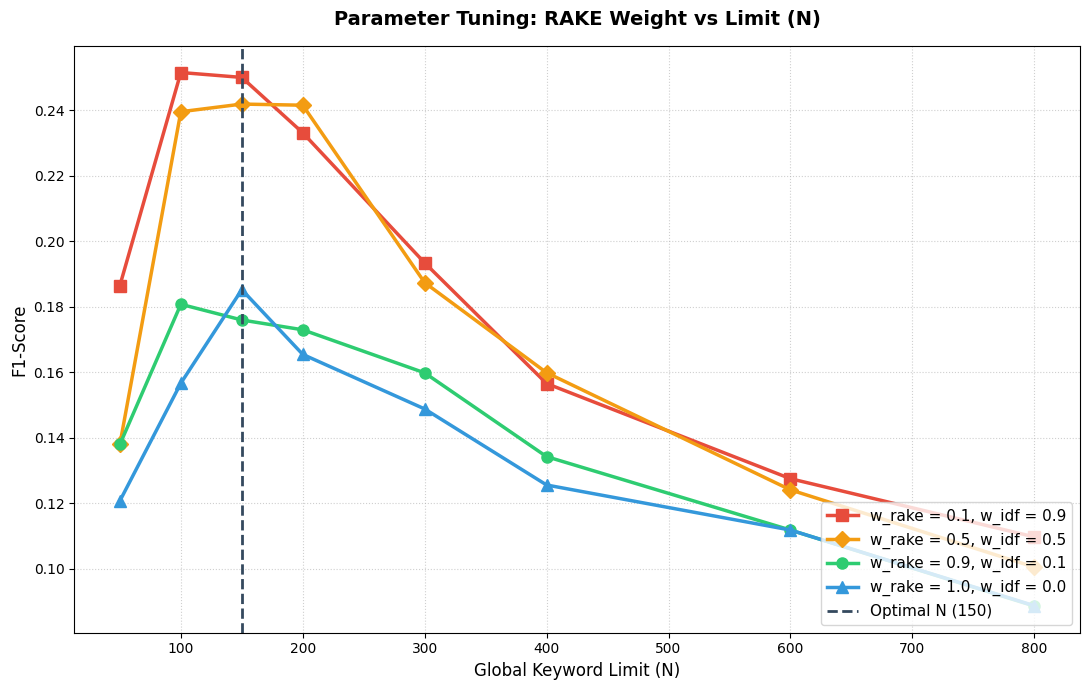

In [25]:
# --- STEP 5: PLOT TUNING RESULTS ---
import matplotlib.pyplot as plt

plt.figure(figsize=(11, 7))

representative_w_rakes = [0.1, 0.5, 0.9, 1.0]
colors_linear = {0.1: '#e74c3c', 0.5: '#f39c12', 0.9: '#2ecc71', 1.0: '#3498db'}
markers_linear = {0.1: 's', 0.5: 'D', 0.9: 'o', 1.0: '^'}

for w_rake in representative_w_rakes:
    results = linear_results[w_rake]
    n_vals = [res['N'] for res in results]
    f1_vals = [res['f1'] for res in results]
    
    plt.plot(n_vals, f1_vals, 
             label=f'w_rake = {w_rake:.1f}, w_idf = {(1.0 - w_rake):.1f}', 
             color=colors_linear[w_rake], 
             marker=markers_linear[w_rake], 
             linewidth=2.5, 
             markersize=8)

plt.axvline(x=opt_N, color='#34495e', linestyle='--', label=f'Optimal N ({opt_N})', linewidth=2)

plt.title('Parameter Tuning: RAKE Weight vs Limit (N)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Global Keyword Limit (N)', fontsize=12)
plt.ylabel('F1-Score', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=11, loc='lower right')
plt.tight_layout()

plt.savefig('tuning_curve.png', dpi=300)
print("Tuning plot saved to 'tuning_curve.png'!")
plt.show()

